# 🤖 机器学习基础（Day 11）

> 本笔记对应 **2026 李宏毅机器学习入门** 系列视频的 **第一讲** 与 **第二讲**：
> - **第一讲：机器学习基本概念简介** —— 机器学习三大类型、训练三步曲、损失函数、梯度下降、学习率、过拟合与正则化
> - **第二讲：深度学习基本概念简介** —— 神经网络、神经元、层、激活函数、为什么"深"有效
>
> 📺 视频链接：https://www.bilibili.com/video/BV1RnikBvE8m

**学习安排：**

**上午（3h）—— 第一讲 机器学习基本概念**

1. 机器学习是什么：让机器"自动找一个函数"
2. 三大类型：回归 / 分类 / 结构化学习
3. 训练三步曲：模型（函数）→ 损失函数 → 优化（梯度下降）
4. 损失函数、梯度下降、学习率
5. 过拟合、欠拟合与正则化

**下午（3h）—— 第二讲 深度学习基本概念**

6. 神经网络与神经元
7. 激活函数（Sigmoid / tanh / ReLU）
8. 层、深度与"为什么深有效"
9. 用代码从零跑通一个小型神经网络（异或 XOR）

> ⚠️ **运行提示**：请从第一个代码单元格开始**按顺序**运行，后面的代码会用到前面定义好的变量与函数。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 让 matplotlib 能正常显示中文（Windows 常见字体）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False   # 让负号 "-" 正常显示

# 本笔记统一使用的颜色（与 Day10 风格一致）
蓝 = '#2b7bba'
橙 = '#e69f00'
灰 = '#999999'
红 = '#d62728'
绿 = '#2ca02c'

print("✓ 环境准备完成")

✓ 环境准备完成


# 🎓 第一讲：机器学习基本概念简介

## 1. 机器学习是什么：让机器"自动找一个函数"

传统程序是**人写死规则**：`if 规则 then 结果`。而机器学习是**让机器自己从数据里"学"出一个函数**。

一句话概括：

$$\text{机器学习} = \text{根据数据，自动找出一个函数 } f:\ \text{输入}\to\text{输出}$$

- **输入（input）**：一张图片、一段语音、一行表格数据……
- **输出（output）**：一个数值、一个类别、一段文字……
- **这个函数 $f$**：就是"模型"（model），由一堆参数决定。

> 李宏毅老师最经典的一句话：**机器学习就是让机器自己寻找一个函数**。你给它数据和目标，它负责把"输入 → 输出"的映射找出来。

根据"输出长什么样"，机器学习分三大类（下面专门讲）：
- 输出是**数值** → **回归（Regression）**
- 输出是**类别** → **分类（Classification）**
- 输出是**结构**（一句话、一张图）→ **结构化学习（Structured Learning）**

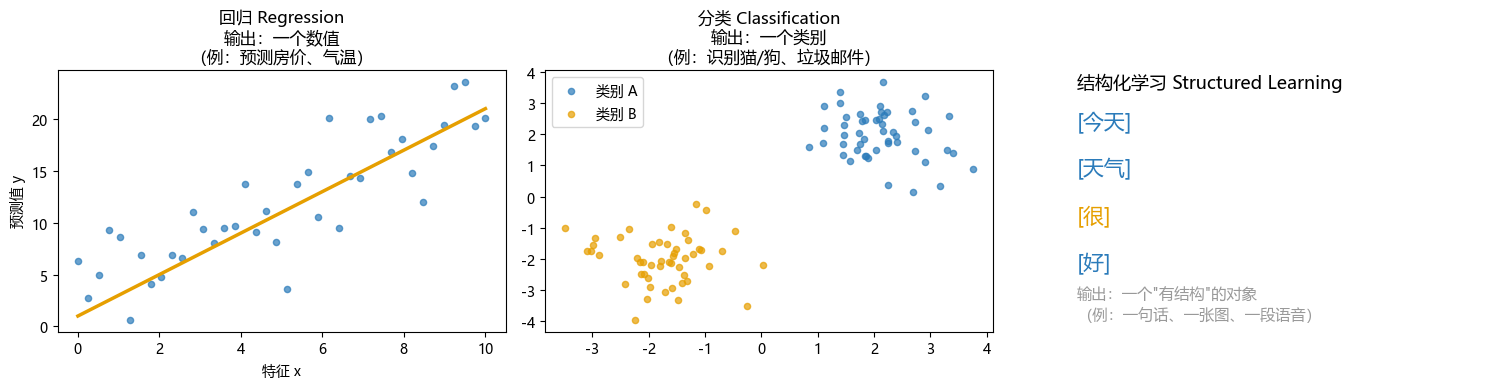

In [2]:
# ---- 机器学习三大类型：回归 / 分类 / 结构化学习 ----
np.random.seed(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ① 回归：输出一个数值（连续）
x = np.linspace(0, 10, 40)
y = 2 * x + 1 + np.random.randn(40) * 3
axes[0].scatter(x, y, color=蓝, alpha=0.7, s=20)
axes[0].plot(x, 2 * x + 1, color=橙, lw=2.5)
axes[0].set_title('回归 Regression\n输出：一个数值\n（例：预测房价、气温）')
axes[0].set_xlabel('特征 x'); axes[0].set_ylabel('预测值 y')

# ② 分类：输出一个类别（离散）
np.random.seed(1)
A = np.random.randn(50, 2) * 0.8 + [2, 2]
B = np.random.randn(50, 2) * 0.8 + [-2, -2]
axes[1].scatter(A[:, 0], A[:, 1], color=蓝, alpha=0.7, s=20, label='类别 A')
axes[1].scatter(B[:, 0], B[:, 1], color=橙, alpha=0.7, s=20, label='类别 B')
axes[1].set_title('分类 Classification\n输出：一个类别\n（例：识别猫/狗、垃圾邮件）')
axes[1].legend()

# ③ 结构化学习：输出一个有结构的东西（示意：让机器输出一句话）
句子 = ['今天', '天气', '很', '好']
axes[2].axis('off')
for i, w in enumerate(句子):
    axes[2].text(0.1, 0.78 - i * 0.18, f'[{w}]', fontsize=15,
                 color=[蓝, 蓝, 橙, 蓝][i], transform=axes[2].transAxes)
axes[2].text(0.1, 0.93, '结构化学习 Structured Learning', fontsize=13, transform=axes[2].transAxes)
axes[2].text(0.1, 0.05, '输出：一个"有结构"的对象\n（例：一句话、一张图、一段语音）',
             fontsize=11, color=灰, transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

## 2. 三大类型 + 学习方式（监督 / 无监督 / 强化）

### 2.1 按"输出"分类

| 类型 | 输出 | 典型例子 |
| --- | --- | --- |
| **回归 Regression** | 一个**数值** | 预测房价、气温、PM2.5、股票 |
| **分类 Classification** | 一个**类别** | 猫狗识别、垃圾邮件、是否生病 |
| **结构化学习** | 一个**结构** | 机器翻译、语音识别、生成图像（大语言模型 LLM 就是它） |

### 2.2 按"有没有标准答案"分类

- **监督学习（Supervised Learning）**：训练数据**带标签**（有标准答案）。让模型学"输入 → 正确答案"的映射。回归、分类大多属于这一类。
- **无监督学习（Unsupervised Learning）**：数据**没有标签**。让机器自己发现数据里的结构（比如聚类、降维，Day10 的 PCA 就是无监督）。
- **强化学习（Reinforcement Learning）**：没有标准答案，只有"奖励/惩罚"信号，机器通过试错逐步学会策略（比如 AlphaGo 下棋）。

> 本系列视频**主线是监督学习**（回归、分类），先把这个吃透，再谈别的。

## 3. 训练三步曲：模型 → 损失 → 优化

李宏毅老师把"训练一个机器学习模型"总结成**三个步骤**，贯穿整个系列：

1. **Step 1 定义模型（Function with unknown parameters）**：先"猜"一个函数的形式，里面带着一些**未知参数**。例如线性模型 $y = w\cdot x + b$，未知参数就是 $w$ 和 $b$。

2. **Step 2 定义损失（Loss）**：用一个"损失函数" $L(w,b)$ 来衡量——这组参数**有多差**。损失越大越差，越小越好。

3. **Step 3 优化（Optimization）**：找一组参数，让损失 $L$ **最小**。最常用的方法就是**梯度下降（Gradient Descent）**。

> 记住这个流程，后面学任何模型（线性回归、逻辑回归、神经网络）都是套这三步。

训练结果：w ≈ 1.986（真实 2.0），b ≈ 0.998（真实 1.0）
损失从 4.32 一路降到 0.0118


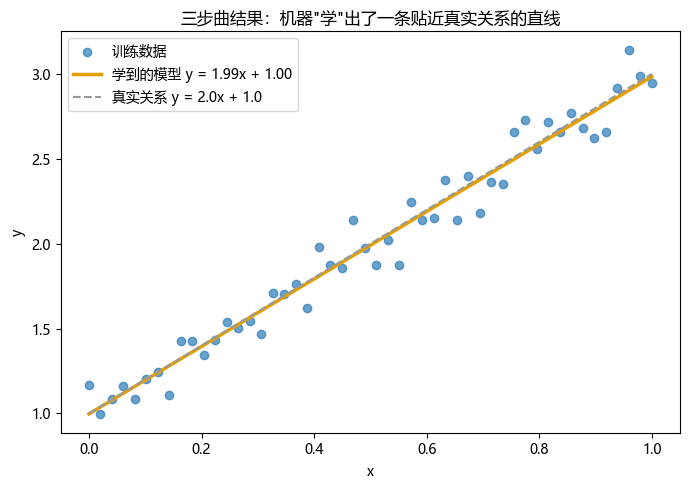

In [3]:
# ---- 训练三步曲完整演示：用线性模型 y = w·x + b 拟合数据 ----
np.random.seed(7)

# 造一批"带噪声"的数据，真实关系是 y = 2x + 1（但我们假装不知道）
X = np.linspace(0, 1, 50)                            # 特征 x，归一化到 [0,1] 让梯度下降更稳
真实w, 真实b = 2.0, 1.0
y = 真实w * X + 真实b + np.random.randn(50) * 0.1    # 目标值，加一点噪声

# ============ Step 1：定义模型（带未知参数的函数）============
def 模型(x, w, b):
    return w * x + b          # 线性模型，未知参数 = w, b

# ============ Step 2：定义损失（MSE 均方误差）============
def 损失(w, b):
    y_pred = 模型(X, w, b)
    return np.mean((y_pred - y) ** 2)     # 平均平方误差

# ============ Step 3：优化（梯度下降）============
w, b = 0.0, 0.0                 # 随便给个初始参数
学习率 = 0.2
轨迹 = [(w, b, 损失(w, b))]

for _ in range(300):
    y_pred = 模型(X, w, b)
    # MSE 对 w、b 的梯度（求偏导）
    dw = np.mean(2 * (y_pred - y) * X)     # ∂L/∂w
    db = np.mean(2 * (y_pred - y))         # ∂L/∂b
    w -= 学习率 * dw                        # 参数沿着负梯度方向更新
    b -= 学习率 * db
    轨迹.append((w, b, 损失(w, b)))

print(f"训练结果：w ≈ {w:.3f}（真实 {真实w}），b ≈ {b:.3f}（真实 {真实b}）")
print(f"损失从 {轨迹[0][2]:.2f} 一路降到 {轨迹[-1][2]:.4f}")

# 画出拟合结果
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X, y, color=蓝, alpha=0.7, label='训练数据')
ax.plot(X, 模型(X, w, b), color=橙, lw=2.5, label=f'学到的模型 y = {w:.2f}x + {b:.2f}')
ax.plot(X, 模型(X, 真实w, 真实b), color=灰, lw=1.5, ls='--', label=f'真实关系 y = {真实w}x + {真实b}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('三步曲结果：机器"学"出了一条贴近真实关系的直线')
ax.legend()
plt.tight_layout()
plt.show()

## 4. 损失函数 Loss：衡量参数"有多差"

损失函数 $L(\theta)$ 的输入是**一组参数** $\theta$，输出是一个**数**——这组参数有多"烂"。

常用的几种（回归 / 分类不同）：

- **均方误差 MSE**：$L = \frac{1}{n}\sum_i (\hat y_i - y_i)^2$，误差的平方和，对"大误差"惩罚更狠，回归常用。
- **平均绝对误差 MAE**：$L = \frac{1}{n}\sum_i |\hat y_i - y_i|$，对异常值不那么敏感。
- **交叉熵 Cross-Entropy**：分类问题专用，衡量两个概率分布有多像（后面逻辑回归、神经网络里会遇到）。

> 一句话：**损失函数就是"打分表"**，给每组参数打分，分数越低（损失越小）参数越好。优化的目标就是让这个分数尽量低。

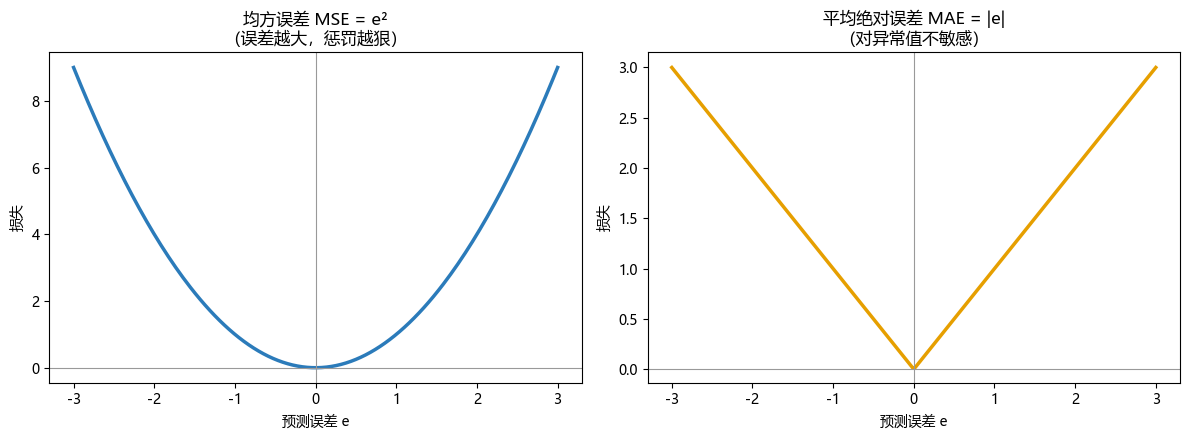

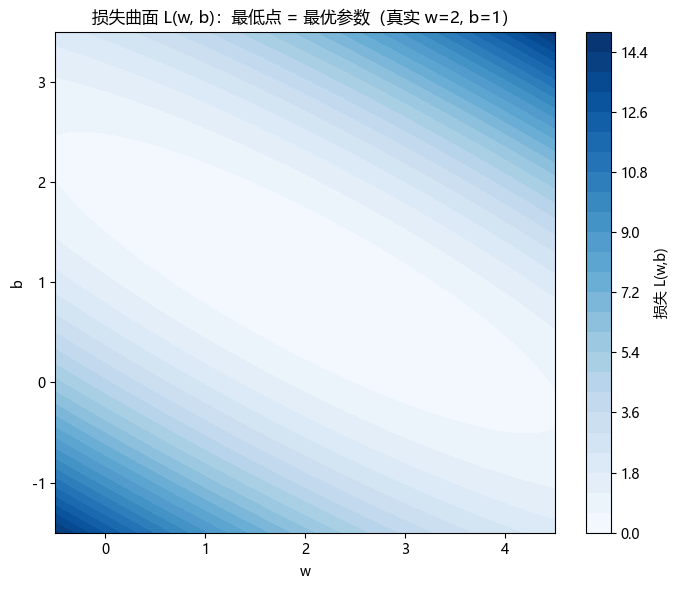

In [4]:
# ---- 损失函数可视化：误差 e 越大，损失越大 ----
e = np.linspace(-3, 3, 200)     # 预测误差 e = y_pred - y

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# MSE：平方
axes[0].plot(e, e**2, color=蓝, lw=2.5)
axes[0].axhline(0, color=灰, lw=0.8); axes[0].axvline(0, color=灰, lw=0.8)
axes[0].set_title('均方误差 MSE = e²\n（误差越大，惩罚越狠）')
axes[0].set_xlabel('预测误差 e'); axes[0].set_ylabel('损失')

# MAE：绝对值
axes[1].plot(e, np.abs(e), color=橙, lw=2.5)
axes[1].axhline(0, color=灰, lw=0.8); axes[1].axvline(0, color=灰, lw=0.8)
axes[1].set_title('平均绝对误差 MAE = |e|\n（对异常值不敏感）')
axes[1].set_xlabel('预测误差 e'); axes[1].set_ylabel('损失')

plt.tight_layout()
plt.show()

# 损失曲面：L(w, b) 是一口"碗"（复用上面 cell 的 X、y 和 损失()）
ws = np.linspace(-0.5, 4.5, 80)
bs = np.linspace(-1.5, 3.5, 80)
W, B = np.meshgrid(ws, bs)
Z = np.array([[损失(w, b) for w in ws] for b in bs])

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(W, B, Z, levels=25, cmap='Blues')
fig.colorbar(c, label='损失 L(w,b)')
ax.set_xlabel('w'); ax.set_ylabel('b')
ax.set_title('损失曲面 L(w, b)：最低点 = 最优参数（真实 w=2, b=1）')
plt.tight_layout()
plt.show()

## 5. 梯度下降 Gradient Descent：一步步滑向最低点

优化就是**找损失最小的参数**。怎么找？**梯度下降**是机器学习的核心算法：

$$\theta \leftarrow \theta - \eta \cdot \nabla L(\theta)$$

- $\nabla L(\theta)$ 是**梯度**（Day10 讲过）：指向损失**上升最快**的方向；
- 我们要**减小**损失，所以朝**负梯度**方向走一小步；
- $\eta$ 叫**学习率（learning rate）**，控制每步走多大。

就像一个人闭着眼站在山坡上，感受脚下的坡度，**每次朝最陡的下坡方向走一小步**，反复迭代，最终走到谷底。

**两个常见问题：**

- **局部最小值（local minimum）**：山谷不止一个时，可能陷在"小坑"里出不来，找不到全局最低；
- **鞍点（saddle point）**：某个方向是下坡、另一个方向是上坡，看起来"平"但可以继续走。

> 在深度学习里，人们发现"局部最小值"其实没那么可怕，真正的问题是**鞍点**和损失曲面的形状（后面会讲）。

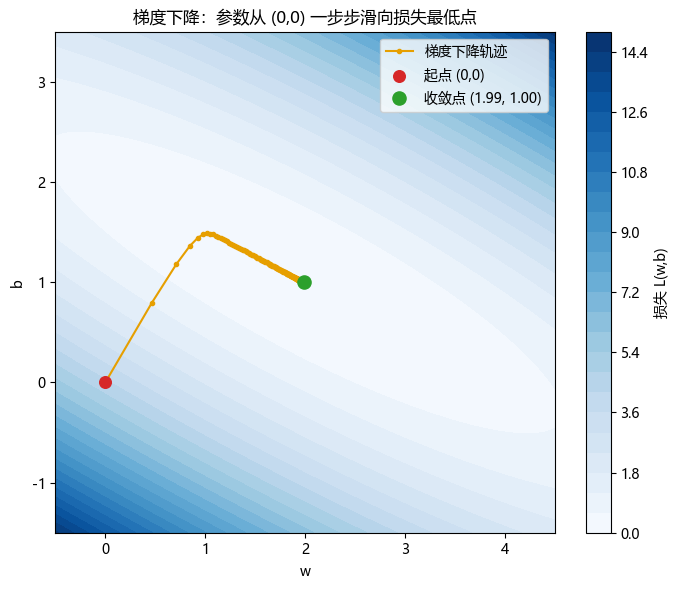

In [5]:
# ---- 梯度下降轨迹：在损失曲面上看参数怎么"滑"到最低点 ----
轨迹arr = np.array([(w, b) for w, b, _ in 轨迹])   # 复用 cell 里记录的轨迹

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(W, B, Z, levels=25, cmap='Blues')   # 复用损失曲面
fig.colorbar(c, label='损失 L(w,b)')
ax.plot(轨迹arr[:, 0], 轨迹arr[:, 1], 'o-', color=橙, lw=1.5, ms=3, label='梯度下降轨迹')
ax.scatter(*轨迹arr[0], color=红, s=70, zorder=5, label='起点 (0,0)')
ax.scatter(*轨迹arr[-1], color=绿, s=90, zorder=5, label=f'收敛点 ({w:.2f}, {b:.2f})')
ax.set_xlabel('w'); ax.set_ylabel('b')
ax.set_title('梯度下降：参数从 (0,0) 一步步滑向损失最低点')
ax.legend()
plt.tight_layout()
plt.show()

## 6. 学习率 Learning Rate：步长是门学问

学习率 $\eta$ 决定**每一步走多大**，这是训练中最常调的超参数：

| 学习率 | 现象 |
| --- | --- |
| **太小** | 收敛极慢，训练很久都到不了谷底 |
| **合适** | 平稳、快速地收敛 |
| **太大** | 震荡、甚至**发散**（损失越训越大，直接飞出谷底） |

> 一句话：学习率太小像"蚂蚁爬"，太大像"青蛙乱跳"。合适的值需要实验来挑（或交给后面讲的自适应学习率方法，比如 Adam）。

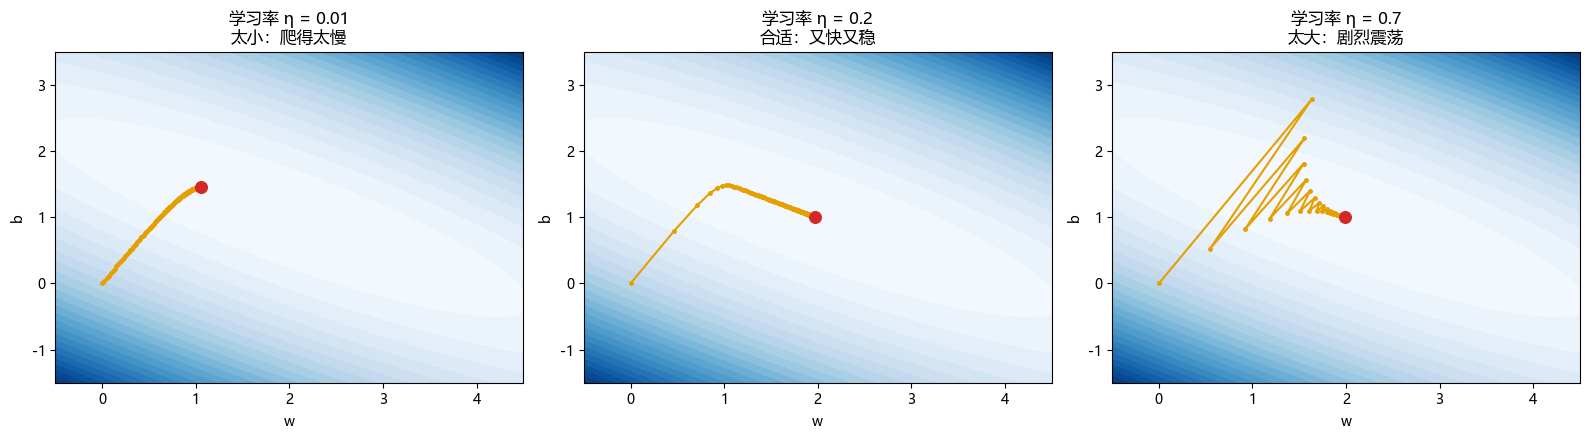

In [6]:
# ---- 不同学习率对梯度下降的影响 ----
def 梯度下降(学习率, 初始=(0.0, 0.0), 步数=150):
    w, b = 初始
    轨 = [(w, b)]
    for _ in range(步数):
        y_pred = 模型(X, w, b)
        dw = np.mean(2 * (y_pred - y) * X)
        db = np.mean(2 * (y_pred - y))
        w -= 学习率 * dw
        b -= 学习率 * db
        轨.append((w, b))
    return np.array(轨)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, lr, t in zip(axes, [0.01, 0.2, 0.7], ['太小：爬得太慢', '合适：又快又稳', '太大：剧烈震荡']):
    轨 = 梯度下降(lr)
    ax.contourf(W, B, Z, levels=25, cmap='Blues')
    ax.plot(轨[:, 0], 轨[:, 1], 'o-', color=橙, lw=1.5, ms=2.5)
    ax.scatter(*轨[-1], color=红, s=70, zorder=5)
    ax.set_title(f'学习率 η = {lr}\n{t}')
    ax.set_xlabel('w'); ax.set_ylabel('b')
plt.tight_layout()
plt.show()

## 7. 过拟合与正则化：模型别"死记硬背"

- **欠拟合（underfitting）**：模型太简单，连训练数据都拟合不好（偏差高）。比如用一条直线去拟合一个明显是曲线的数据。
- **过拟合（overfitting）**：模型太复杂，把训练数据的**噪声**都"背"下来了，换一批新数据就崩（方差高）。就像学生只会背题，不会举一反三。
- **正则化（regularization）**：给损失函数加一个"惩罚项"，限制参数不要太大，从而**抑制过拟合**。常见的有：
  - **L2 正则化（岭回归 Ridge）**：$L + \lambda \sum w^2$，让参数整体变小；
  - **L1 正则化（套索 Lasso）**：$L + \lambda \sum |w|$，能让部分参数直接变成 0（稀疏）。

> 本系列后面（第 41~50 讲）会专门细讲 L1/L2 正则化、Lasso、Ridge、ElasticNet，这里先建立"过拟合 = 模型把噪声也学了"的直觉。

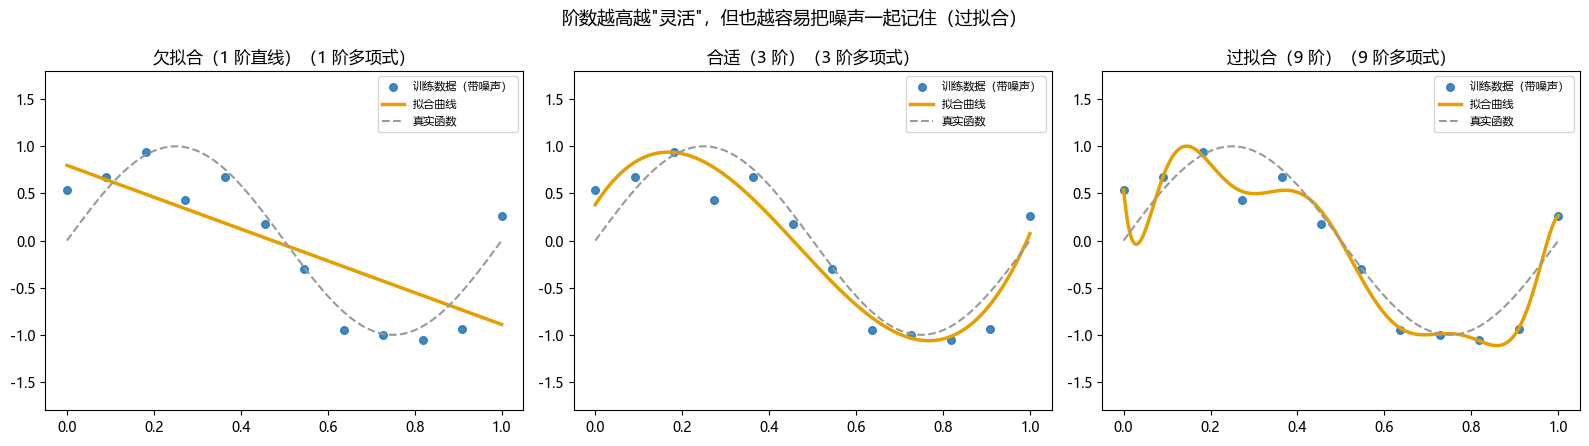

In [7]:
# ---- 欠拟合 / 合适 / 过拟合：多项式阶数对比 ----
np.random.seed(3)
x = np.linspace(0, 1, 12)
y真实 = np.sin(2 * np.pi * x)      # 真实关系是一个正弦波
y = y真实 + np.random.randn(12) * 0.3

xs = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, 阶数, t in zip(axes, [1, 3, 9], ['欠拟合（1 阶直线）', '合适（3 阶）', '过拟合（9 阶）']):
    系数 = np.polyfit(x, y, 阶数)              # 多项式拟合
    ax.scatter(x, y, color=蓝, s=30, alpha=0.9, label='训练数据（带噪声）')
    ax.plot(xs, np.polyval(系数, xs), color=橙, lw=2.5, label='拟合曲线')
    ax.plot(xs, np.sin(2 * np.pi * xs), color=灰, lw=1.5, ls='--', label='真实函数')
    ax.set_title(f'{t}（{阶数} 阶多项式）')
    ax.set_ylim(-1.8, 1.8)
    ax.legend(fontsize=8)

plt.suptitle('阶数越高越"灵活"，但也越容易把噪声一起记住（过拟合）', fontsize=13)
plt.tight_layout()
plt.show()

## 8. 三个"进阶名词"速览（后面会逐一深挖）

这些是视频标题里点名的核心知识点，先建立印象，本系列后续讲次会详细展开：

- **特征工程（Feature Engineering）**：原始数据往往不能直接喂给模型，需要**清洗、缩放、组合**特征。典型例子是**归一化**（把不同量纲的特征缩到同一范围，如 Min-Max、Z-Score），否则量纲大的特征会"压过"小的特征。→ 对应第 36~40 讲。

- **Batch（批）**：一次梯度更新用多少条数据。
  - **BGD 批量梯度下降**：用**全部**数据算一次梯度（稳，但慢）；
  - **SGD 随机梯度下降**：每次只用**1 条**（快，但抖）；
  - **MBGD 小批量**：每次用**一小批**（折中，最常用）。→ 对应第 22~35 讲。

- **Momentum（动量）**：梯度下降时"带上惯性"，像球滚下山，能更快冲过平坦区、减少震荡。公式大致是 $v \leftarrow \gamma v + \eta\nabla L,\ \ \theta\leftarrow\theta - v$。→ 是 Adam 等优化器的基础。

# 🧠 第二讲：深度学习基本概念简介

## 1. 神经网络：一大堆"神经元"搭起来的函数

第一讲说机器学习是"找一个函数"。**神经网络（Neural Network）就是一种特别能拟合复杂函数的模型**——它由许多个**神经元（neuron）**按层连接而成。

一个**神经元**做的事很简单，就两步：

$$a = \sigma\Big(\underbrace{w_1x_1 + w_2x_2 + \cdots + b}_{\text{加权求和 } z}\Big)$$

1. **加权求和**：把输入 $x$ 各自乘上一个**权重** $w$，加起来再加一个**偏置** $b$，得到 $z$；
2. **激活函数**：把 $z$ 送进一个非线性函数 $\sigma(\cdot)$（比如 Sigmoid、ReLU），得到输出 $a$。

> 单个神经元 ≈ 逻辑回归。而把很多神经元**一层层叠起来**，就有了表达复杂函数的能力——这就是"神经网络"。

In [8]:
# ---- 单个神经元的计算：加权求和 → 激活函数 ----
def 神经元(x, w, b, 激活=np.tanh):
    """一个神经元：z = w·x + b，然后过激活函数 a = 激活(z)。"""
    z = np.dot(w, x) + b
    return z, 激活(z)

# 一个 3 个输入、3 个神经元的简单例子
x = np.array([0.5, -0.3, 0.8])           # 输入（3 个特征）
W = np.array([[0.2, -0.5, 0.4],          # 3 个神经元各自的权重
              [0.8, 0.1, -0.7],
              [-0.3, 0.6, 0.5]])
b = np.array([0.1, -0.2, 0.0])

z, a = 神经元(x, W, b)                    # 一次算出 3 个神经元的输出
print("加权求和 z =", np.round(z, 3))
print("激活输出 a =", np.round(a, 3))
print("\n→ 原始线性加权 z 经过激活函数后，变成非线性的输出 a。")
print("→ 这就是神经网络的'非线性'来源：没有激活函数，无论多少层都等价于一条直线。")

加权求和 z = [ 0.67 -0.39  0.07]
激活输出 a = [ 0.585 -0.371  0.07 ]

→ 原始线性加权 z 经过激活函数后，变成非线性的输出 a。
→ 这就是神经网络的'非线性'来源：没有激活函数，无论多少层都等价于一条直线。


## 2. 激活函数：给网络注入"非线性"

如果没有激活函数，神经网络只是"线性变换的堆叠"，等价于**一个线性模型**——再深也没用。激活函数让网络能拟合**任意复杂**的函数。

常用的几种：

| 激活函数 | 公式 | 特点 |
| --- | --- | --- |
| **Sigmoid** | $\sigma(z)=\frac{1}{1+e^{-z}}$ | 输出压到 (0,1)，早期常用，但深层网络里容易"梯度消失" |
| **tanh** | $\tanh(z)$ | 输出压到 (-1,1)，比 Sigmoid 稍好 |
| **ReLU** | $\max(0, z)$ | 计算快、缓解梯度消失，**现代网络最常用** |

> 现代深度学习里，隐藏层基本都用 **ReLU**（或它的变体）；只有输出层会根据任务选：回归用线性输出，二分类用 Sigmoid，多分类用 Softmax。

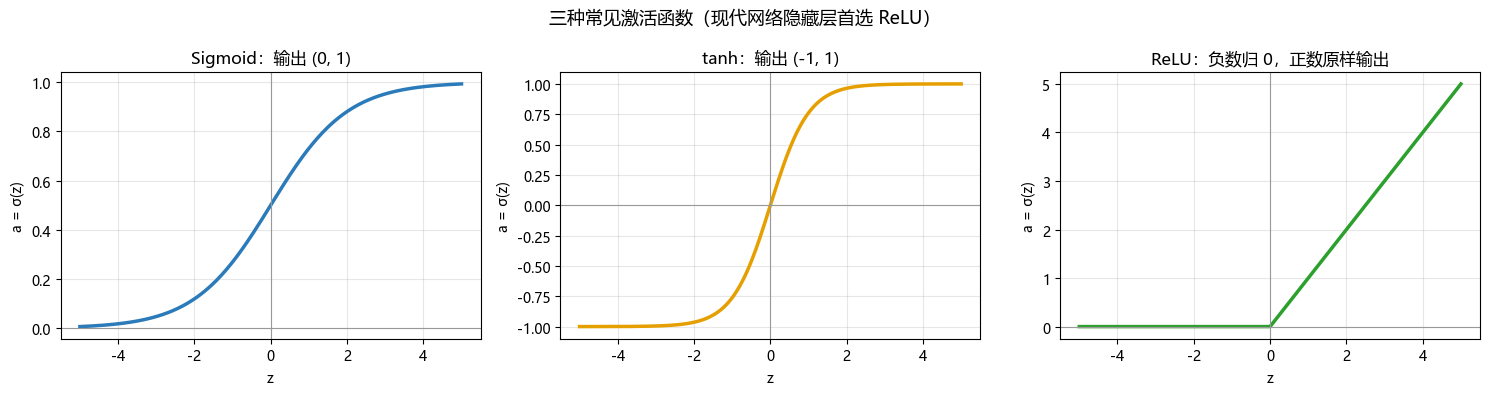

In [9]:
# ---- 三种常用激活函数可视化 ----
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(z, sigmoid(z), color=蓝, lw=2.5)
axes[0].set_title('Sigmoid：输出 (0, 1)')
axes[1].plot(z, np.tanh(z), color=橙, lw=2.5)
axes[1].set_title('tanh：输出 (-1, 1)')
axes[2].plot(z, np.maximum(0, z), color=绿, lw=2.5)
axes[2].set_title('ReLU：负数归 0，正数原样输出')

for ax in axes:
    ax.axhline(0, color=灰, lw=0.8); ax.axvline(0, color=灰, lw=0.8)
    ax.set_xlabel('z'); ax.set_ylabel('a = σ(z)')
    ax.grid(alpha=0.3)

plt.suptitle('三种常见激活函数（现代网络隐藏层首选 ReLU）', fontsize=13)
plt.tight_layout()
plt.show()

## 3. 层、深度：把神经元叠起来

神经网络按**层（layer）**组织：

- **输入层（input layer）**：原始特征，不参与计算，只是"入口"；
- **隐藏层（hidden layer）**：中间那些层，负责层层提取特征；
- **输出层（output layer）**：给出最终结果（数值 / 类别 / 概率）。

**"深度" = 隐藏层的层数**。层数多 → 就叫**深度学习（Deep Learning）**。所以：

> **深度学习 = 有很多隐藏层的神经网络**。名字很玄，本质就是"又深又宽的神经网络"。

**为什么"深"有效？** 直觉上，网络是一层层递进的：
- 底层学到**简单特征**（边缘、颜色、简单模式）；
- 中层组合成**较复杂特征**（轮廓、局部形状）；
- 高层组合成**语义特征**（人脸、物体、整个句子的含义）。

一层层抽象下去，就能表达越来越复杂的函数。

最终损失(MSE) = 0.0002

异或真值表（学完后）：
  (np.int64(0), np.int64(0)) -> 真实 0，预测 0 ✓
  (np.int64(0), np.int64(1)) -> 真实 1，预测 1 ✓
  (np.int64(1), np.int64(0)) -> 真实 1，预测 1 ✓
  (np.int64(1), np.int64(1)) -> 真实 0，预测 0 ✓


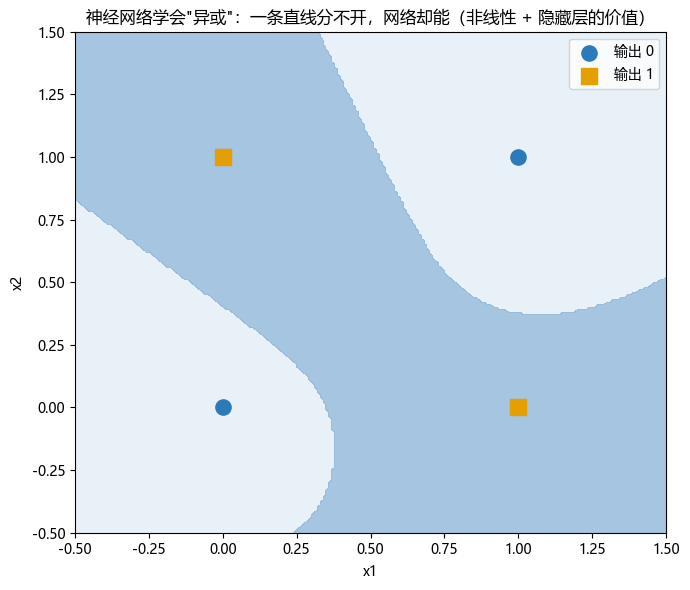

In [10]:
# ---- 从零实现一个两层神经网络，学习"异或 XOR"（单条直线分不开的问题）----
np.random.seed(0)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])          # 输入 (4, 2)
y = np.array([[0], [1], [1], [0]])                       # 目标 (4, 1)：异或

输入维度, 隐藏维度, 输出维度 = 2, 4, 1
W1 = np.random.randn(输入维度, 隐藏维度) * 0.5            # 第一层权重 (2, 4)
b1 = np.zeros(隐藏维度)
W2 = np.random.randn(隐藏维度, 输出维度) * 0.5            # 第二层权重 (4, 1)
b2 = np.zeros(输出维度)

def 前向(x):
    z1 = x @ W1 + b1
    a1 = np.tanh(z1)              # 隐藏层激活：tanh
    z2 = a1 @ W2 + b2
    a2 = 1 / (1 + np.exp(-z2))    # 输出层激活：sigmoid（输出概率）
    return a1, a2

学习率 = 0.5
for epoch in range(3000):
    a1, a2 = 前向(X)
    # ---- 反向传播（链式法则求梯度）----
    dz2 = (a2 - y) * a2 * (1 - a2)          # MSE 损失 + sigmoid 输出的梯度
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0)
    dz1 = (dz2 @ W2.T) * (1 - a1**2)        # tanh 的导数 = 1 - tanh²
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)
    # ---- 梯度下降更新 ----
    W1 -= 学习率 * dW1; b1 -= 学习率 * db1
    W2 -= 学习率 * dW2; b2 -= 学习率 * db2

_, a2 = 前向(X)
print(f"最终损失(MSE) = {np.mean((a2 - y) ** 2):.4f}")
print("\n异或真值表（学完后）：")
for 输入, 目标 in zip(X, y):
    _, a2i = 前向(输入.reshape(1, -1))
    预测 = 1 if a2i[0, 0] > 0.5 else 0
    print(f"  {tuple(输入)} -> 真实 {目标[0]}，预测 {预测} {'✓' if 预测 == 目标[0] else '✗'}")

# ---- 决策边界：单条直线分不开 XOR，但网络能画出弯曲的边界 ----
xx = np.linspace(-0.5, 1.5, 200)
XX, YY = np.meshgrid(xx, xx)
_, a2grid = 前向(np.c_[XX.ravel(), YY.ravel()])
Zgrid = (a2grid.reshape(XX.shape) > 0.5).astype(int)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(XX, YY, Zgrid, alpha=0.4, cmap='Blues', levels=[-0.5, 0.5, 1.5])
ax.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], s=120, color=蓝, label='输出 0')
ax.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], s=120, color=橙, marker='s', label='输出 1')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('神经网络学会"异或"：一条直线分不开，网络却能（非线性 + 隐藏层的价值）')
ax.legend()
plt.tight_layout()
plt.show()

## 4. 训练神经网络，还是那"三步曲"

别被"深度学习"吓到——训练一个神经网络，本质上还是第一讲那**三步曲**：

1. **模型**：把网络结构（几层、每层几个神经元、用什么激活）定下来，就是"带未知参数（权重 $w$、偏置 $b$）的函数"；
2. **损失**：用一个损失函数（回归用 MSE、分类用交叉熵）衡量输出和真实答案的差距；
3. **优化**：用**梯度下降 + 反向传播（Backpropagation）**，自动算出每一层每个参数的梯度，迭代更新。

> 反向传播只是**链式法则**（微积分里求复合函数导数的法则）在神经网络上的应用，把输出层的误差一层层"传"回前面，本质没有超出第一讲三步曲的框架。

# 🎯 总结

## 第一讲：机器学习基本概念

| 概念 | 一句话直觉 |
| --- | --- |
| **机器学习** | 让机器根据数据自动找一个函数（输入 → 输出） |
| **回归 / 分类 / 结构化** | 输出是数值 / 类别 / 结构 |
| **训练三步曲** | 定义模型 → 定义损失 → 梯度下降优化 |
| **损失函数** | 给参数"打分"的函数，越小越好（MSE / MAE / 交叉熵） |
| **梯度下降** | 每次朝负梯度方向走一小步，逐步滑到最低点 |
| **学习率** | 步长：太小慢、太大震荡发散 |
| **过拟合** | 模型太复杂，把噪声也背下来了；用**正则化**抑制 |
| **特征工程 / Batch / Momentum** | 归一化特征；一次用多少数据更新；带惯性下坡 |

## 第二讲：深度学习基本概念

| 概念 | 一句话直觉 |
| --- | --- |
| **神经元** | 加权求和 + 激活函数，网络的基本单元 |
| **激活函数** | 注入非线性（Sigmoid / tanh / ReLU，现代首选 ReLU） |
| **层 / 深度** | 输入层、隐藏层、输出层；"深度" = 隐藏层层数 |
| **深度学习** | 有很多隐藏层的神经网络，层层提取更抽象的特征 |
| **训练** | 还是三步曲，只是用反向传播自动求梯度 |

## 一句话记住这两讲

> **机器学习 = 找函数；找函数 = 三步曲（模型 → 损失 → 优化）；神经网络 = 用一堆带非线性的神经元搭成的、能拟合任意函数的模型，训练它还是那三步曲。**